<a href="https://colab.research.google.com/github/K121-hash/Wine-Quality-Prediction-Using-Machine-Learning-/blob/main/Wine_quality_prediction_ML.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#1. Project Title

# Wine Quality Prediction Using Machine Learning

## Objective

The aim of this project is to build and compare multiple classification models that predict wine quality based on physicochemical properties such as acidity, density, pH, and alcohol content.

The project evaluates the performance of Random Forest, Stochastic Gradient Descent (SGD), and Support Vector Classifier (SVC) models and determines the most suitable model for deployment.

##2. Import Required Libraries

In [ ]:
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Data preprocessing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Models
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import SGDClassifier
from sklearn.svm import SVC

# Evaluation
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

# Ignore warnings
import warnings
warnings.filterwarnings("ignore")

##3. Load the Dataset

In [ ]:
df = pd.read_excel("/content/drive/MyDrive/WineQualityExcel.xlsx")

# convert to csv
df.to_csv("WineQualitycsv.csv", index=False)

##5. Dataset Overview


This section provides an overview of the Wine Quality dataset, including its dimensions, structure, and statistical summary.

The dataset contains physicochemical properties of wine samples, such as acidity, density, pH, and alcohol content, which are used to predict wine quality.

In [ ]:
# check first few rows
df.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


In [ ]:
# check the tail
df.tail()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
1594,6.2,0.600,0.08,2.0,0.090,32.0,44.0,0.99490,3.45,0.58,10.5,5
1595,5.9,0.550,0.10,2.2,0.062,39.0,51.0,0.99512,3.52,0.76,11.2,6
1596,6.3,0.510,0.13,2.3,0.076,29.0,40.0,0.99574,3.42,0.75,11.0,6
1597,5.9,0.645,0.12,2.0,0.075,32.0,44.0,0.99547,3.57,0.71,10.2,5
1598,6.0,0.310,0.47,3.6,0.067,18.0,42.0,0.99549,3.39,0.66,11.0,6


In [ ]:
df.columns

Index(['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar',
       'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density',
       'pH', 'sulphates', 'alcohol', 'quality'],
      dtype='object')

In [ ]:
#check shape
df.shape

(1599, 12)

In [ ]:
# check dataset information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1599 entries, 0 to 1598
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1599 non-null   float64
 1   volatile acidity      1599 non-null   float64
 2   citric acid           1599 non-null   float64
 3   residual sugar        1599 non-null   float64
 4   chlorides             1599 non-null   float64
 5   free sulfur dioxide   1599 non-null   float64
 6   total sulfur dioxide  1599 non-null   float64
 7   density               1599 non-null   float64
 8   pH                    1599 non-null   float64
 9   sulphates             1599 non-null   float64
 10  alcohol               1599 non-null   float64
 11  quality               1599 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 150.0 KB


In [ ]:
# Dataset descriptive summary
df.describe()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
count,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000
mean,8.319637,0.527821,0.270976,2.538806,0.087467,15.874922,46.467792,0.996747,3.311113,0.658149,10.422983,5.636023
std,1.741096,0.179060,0.194801,1.409928,0.047065,10.460157,32.895324,0.001887,0.154386,0.169507,1.065668,0.807569
min,4.600000,0.120000,0.000000,0.900000,0.012000,1.000000,6.000000,0.990070,2.740000,0.330000,8.400000,3.000000
25%,7.100000,0.390000,0.090000,1.900000,0.070000,7.000000,22.000000,0.995600,3.210000,0.550000,9.500000,5.000000
50%,7.900000,0.520000,0.260000,2.200000,0.079000,14.000000,38.000000,0.996750,3.310000,0.620000,10.200000,6.000000
75%,9.200000,0.640000,0.420000,2.600000,0.090000,21.000000,62.000000,0.997835,3.400000,0.730000,11.100000,6.000000
max,15.900000,1.580000,1.000000,15.500000,0.611000,72.000000,289.000000,1.003690,4.010000,2.000000,14.900000,8.000000


#6. Data Cleaning and preprocessing

In [ ]:
# check missing numbers
df.isnull().sum()

,0
fixed acidity,0
volatile acidity,0
citric acid,0
residual sugar,0
chlorides,0
free sulfur dioxide,0
total sulfur dioxide,0
density,0
pH,0
sulphates,0


In [ ]:
# check for duplicates
df.duplicated().sum()

np.int64(240)

In [ ]:
# Remove duplicates
df = df.drop_duplicates()

In [ ]:
# Check the new shape
df.shape

(1359, 12)

In [ ]:
# Confirm data types
df.dtypes

,0
fixed acidity,float64
volatile acidity,float64
citric acid,float64
residual sugar,float64
chlorides,float64
free sulfur dioxide,float64
total sulfur dioxide,float64
density,float64
pH,float64
sulphates,float64


#Observation

The dataset was examined for missing values, duplicate records, and incorrect data types.

No missing values were found in any of the columns. However, duplicate rows were identified and removed to improve the quality of the dataset and avoid bias during model training.

All features were already stored in the appropriate numerical format, so no further transformations were required at this stage.

##7. Class Distribution of Wine Quality

This section examines how wine quality scores are distributed and whether class imbalance exists.

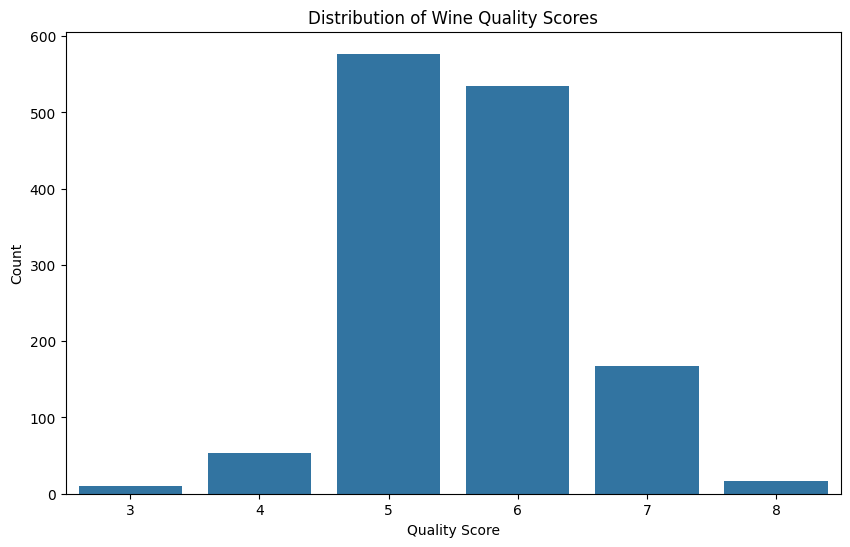

In [ ]:
# visualize quality distribution
plt.figure(figsize=(10, 6))

sns.countplot(
    data=df,
    x="quality"
)

plt.title("Distribution of Wine Quality Scores")
plt.xlabel("Quality Score")
plt.ylabel("Count")

plt.xticks(rotation=0)

plt.show()

## Discussion on Class Imbalance

The class distribution plot shows that the dataset is imbalanced. Wine quality scores of 5 and 6 have the highest number of observations, making them the majority classes. In contrast, quality scores of 3, 4, and 8 have significantly fewer samples and are therefore underrepresented.

This imbalance may affect the performance of machine learning models because they tend to learn patterns from the majority classes more effectively than from the minority classes. As a result, the models may achieve high overall accuracy while performing poorly when predicting rare quality scores.

To address this issue and simplify the classification task, feature engineering techniques such as grouping the quality scores into broader categories (for example, good and bad wine, or low, medium, and high quality) can be applied.

Therefore, it is important to use stratified sampling during the train-test split to preserve the original class distribution in both the training and testing datasets.

## 7. Exploratory Data Analysis

This section explores the distribution of the physicochemical properties of wine, including acidity, density, pH, sulphates, and alcohol content.

Understanding the distribution of these features helps identify patterns, skewness, and possible outliers that may affect model performance.

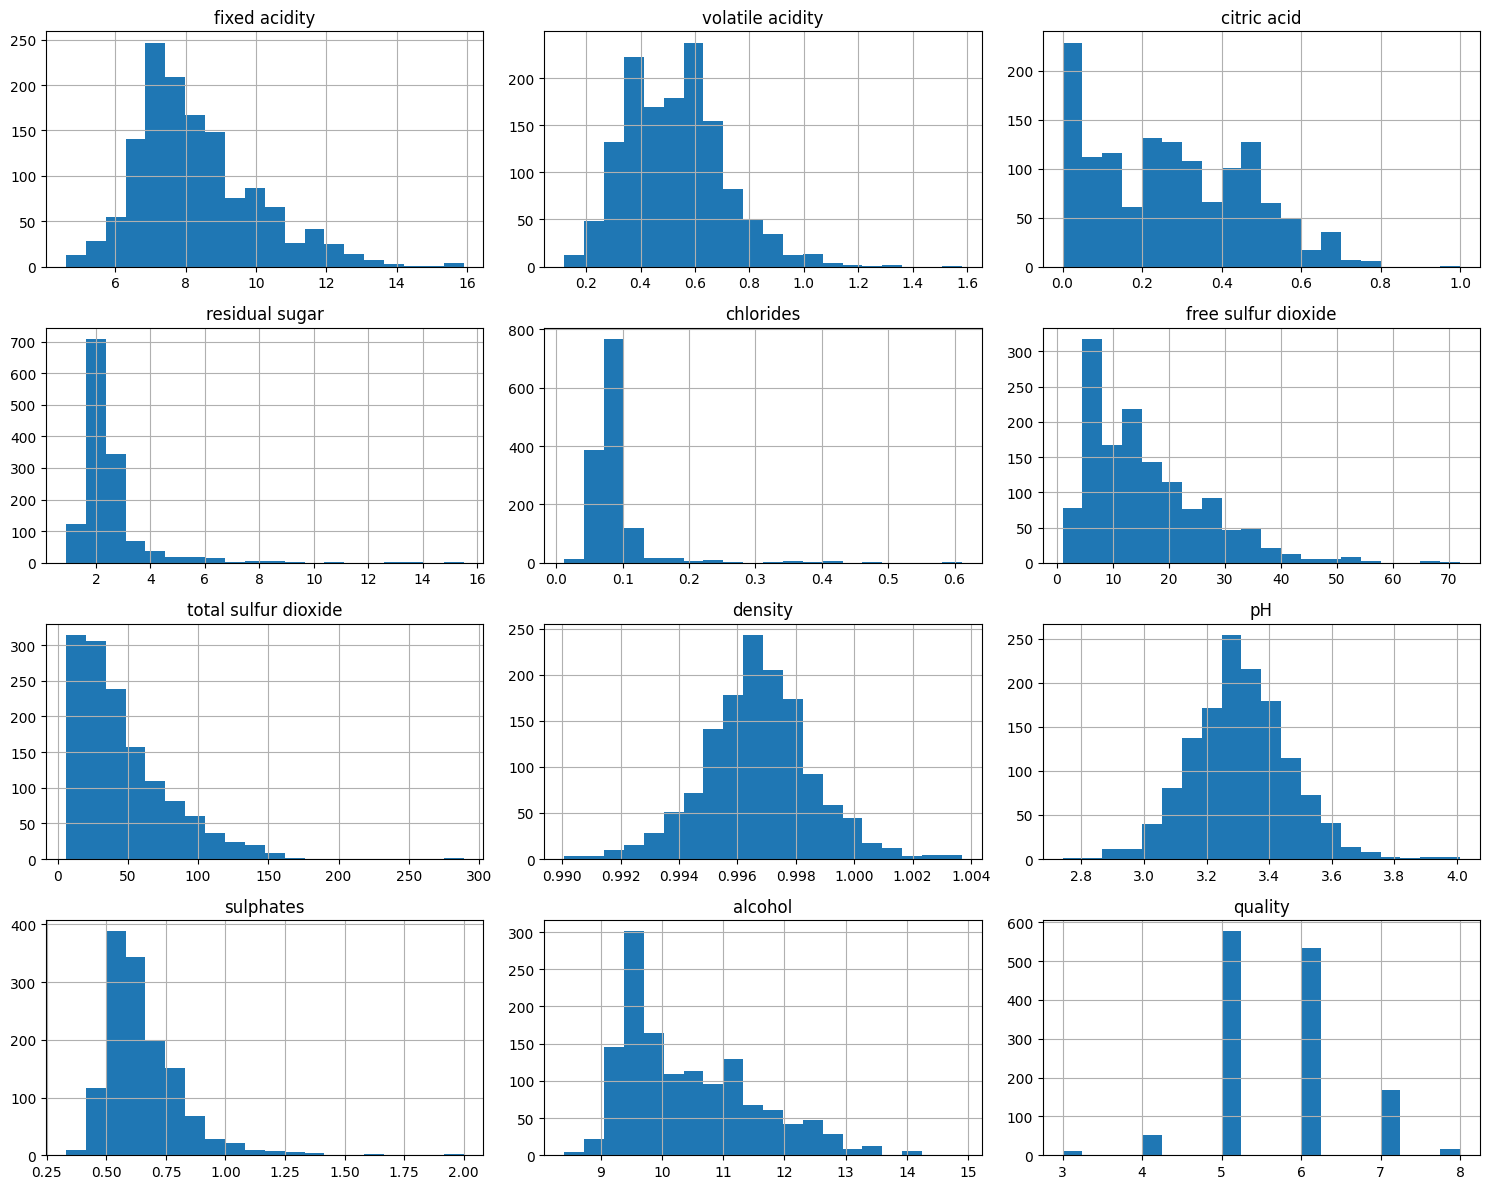

In [ ]:
#Distribution Plots for All Features
df.hist(
    figsize=(15, 12),
    bins=20
)

plt.tight_layout()
plt.show()

## Discussion

The distribution plots reveal that the physicochemical properties of the wine samples exhibit different patterns and ranges.

Most features, such as fixed acidity, density, and pH, appear to follow approximately normal distributions. However, variables such as residual sugar, chlorides, free sulfur dioxide, total sulfur dioxide, and sulphates are positively skewed, indicating the presence of extreme values or outliers.

The alcohol content shows a relatively wide spread, suggesting significant variation among the wine samples. Furthermore, the quality distribution confirms that most wines have quality scores of 5 and 6, while scores of 3, 4, and 8 are less common.

The differences in feature scales indicate that feature scaling will be necessary before training certain machine learning models, particularly SGD and SVC.

##8. Correlation Analysis

A correlation heatmap is used to examine the relationships among the variables and identify which features are most strongly associated with wine quality.

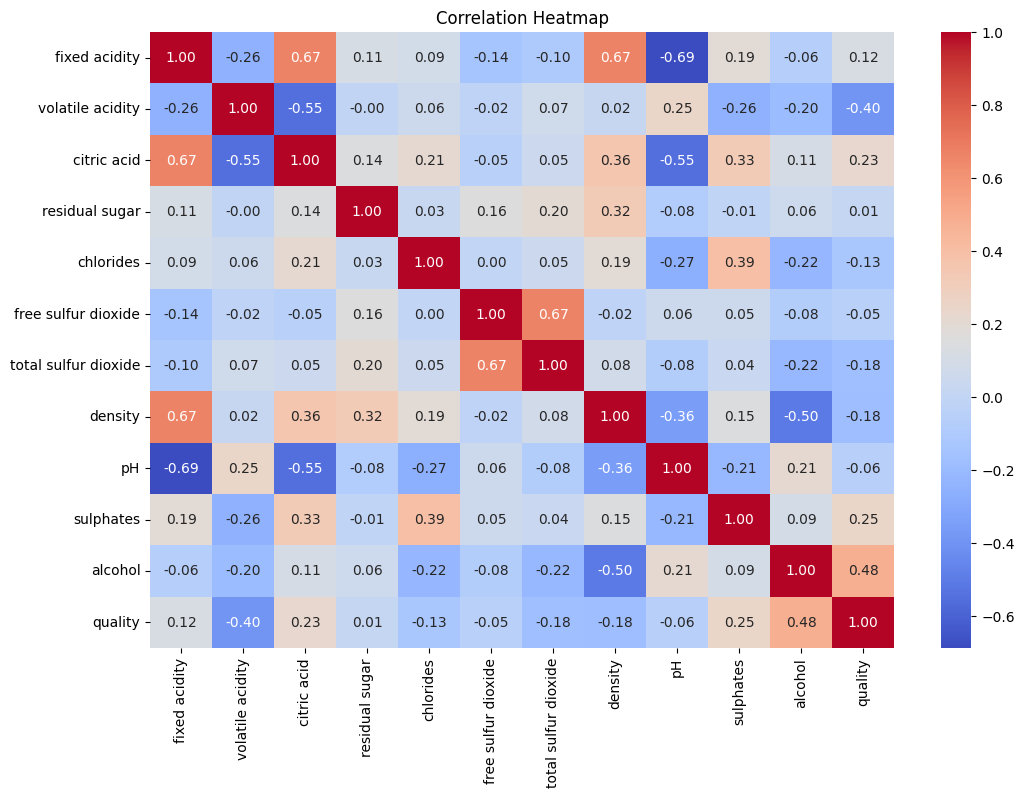

In [ ]:
plt.figure(figsize=(12, 8))

sns.heatmap(
    df.corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")

plt.show()

## Discussion

The correlation heatmap illustrates the relationships between the physicochemical properties and wine quality.

Alcohol exhibits the strongest positive correlation with quality (0.48), indicating that wines with higher alcohol content tend to receive better quality ratings. Sulphates (0.25) and citric acid (0.23) also show positive relationships with wine quality.

In contrast, volatile acidity has the strongest negative correlation with quality (-0.40), suggesting that higher volatile acidity is associated with lower-quality wines. Chlorides (-0.13) and total sulfur dioxide (-0.18) also show weak negative correlations with quality.

Additionally, some features are highly correlated with one another. For example, fixed acidity and pH have a strong negative correlation (-0.69), while fixed acidity and citric acid have a strong positive correlation (0.67).

Overall, alcohol, sulphates, citric acid, and volatile acidity appear to be the most influential factors in determining wine quality.

##9. Feature Engineering

The original wine quality scores range from 3 to 8.

To simplify the classification task, the quality scores are converted into binary classes:

- Good Wine (quality ≥ 7)
- Bad Wine (quality < 7)

This transformation reduces class imbalance and simplifies interpretation.

In [ ]:
# Convert quality into binary classes

df["quality_label"] = np.where(
    df["quality"] >= 7,
    1,
    0
)

df["quality_label"].value_counts()

,count
quality_label,
0,1175
1,184


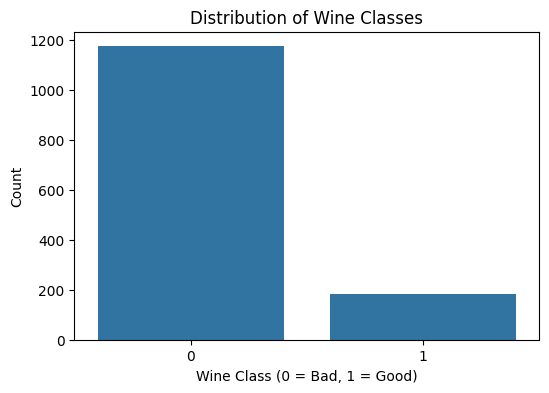

In [ ]:
# visualize the new classes
plt.figure(figsize=(6, 4))

sns.countplot(
    data=df,
    x="quality_label"
)

plt.title("Distribution of Wine Classes")
plt.xlabel("Wine Class (0 = Bad, 1 = Good)")
plt.ylabel("Count")

plt.show()

##10. Train-Test Split

The dataset is divided into features (X) and the target variable (y). The target variable is the binary wine quality label created during feature engineering.

A stratified train-test split is used to preserve the class distribution in both the training and testing sets.

In [ ]:
# Separate features and target variable

X = df.drop(columns=["quality", "quality_label"])
y = df["quality_label"]

In [ ]:
#Split Dataset
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [ ]:
print(X_train.shape)
print(X_test.shape)

(1087, 11)
(272, 11)


##11. Feature Scaling

The wine dataset contains features measured on different scales. For example, alcohol content, pH, and sulfur dioxide have different ranges of values.

Feature scaling is applied to standardize the features so that they have a mean of 0 and a standard deviation of 1. This ensures that features with larger values do not dominate the learning process.

Scaling is particularly important for Stochastic Gradient Descent (SGD) and Support Vector Classifier (SVC), which are sensitive to the magnitude of the input features. Although Random Forest does not require feature scaling, the same scaled dataset is used for all models to maintain consistency.

In [ ]:
# Initialize scaler
scaler = StandardScaler()

# Fit on training data and transform both sets
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

##12. Train Model 1: Random Forest classifier

In [ ]:
from sklearn.ensemble import RandomForestClassifier

# Create the model
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

# Train the model
rf_model.fit(X_train_scaled, y_train)

RandomForestClassifier(random_state=42)

In [ ]:
# make predictions
rf_predictions = rf_model.predict(X_test_scaled)

##13.Train Model 2: SGD Classifier

In [ ]:
sgd = SGDClassifier(
    random_state=42
)

sgd.fit(
    X_train_scaled,
    y_train
)

SGDClassifier(random_state=42)

In [ ]:
# make predictions
sgd_predictions = sgd.predict(X_test_scaled)

##14. Train Model 3: Support Vector Classifier

In [ ]:
svc = SVC(
    random_state=42
)

svc.fit(
    X_train_scaled,
    y_train
)

SVC(random_state=42)

In [ ]:
#make predictions
svc_predictions = svc.predict(X_test_scaled)

##15. Model Evaluation

The performance of the three models is evaluated using the following metrics:

- Accuracy Score
- Classification Report
- Confusion Matrix

These metrics help assess how effectively each model predicts wine quality.

##Random Forest Evaluation

In [ ]:
# Accuracy
rf_accuracy = accuracy_score(y_test, rf_predictions)

print("Random Forest Accuracy:", rf_accuracy)

Random Forest Accuracy: 0.8970588235294118


In [ ]:
# Classification report
print(classification_report(y_test, rf_predictions))

              precision    recall  f1-score   support

           0       0.91      0.98      0.94       235
           1       0.74      0.38      0.50        37

    accuracy                           0.90       272
   macro avg       0.82      0.68      0.72       272
weighted avg       0.89      0.90      0.88       272



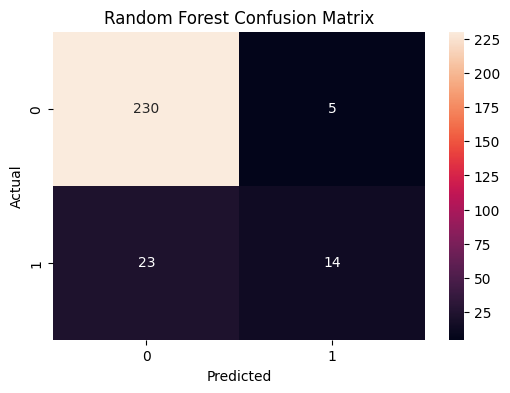

In [ ]:
#confusion matrix
rf_cm = confusion_matrix(y_test, rf_predictions)

plt.figure(figsize=(6, 4))

sns.heatmap(
    rf_cm,
    annot=True,
    fmt="d"
)

plt.title("Random Forest Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

## Discussions

### Accuracy

The Random Forest model achieved an accuracy of **89.71%**, making it the best-performing model among all the models tested.

### Classification Report

The model performed very well in predicting class **0**, achieving high precision, recall, and F1-score values. However, its performance on class **1** was lower, mainly because the dataset is imbalanced.

The weighted average F1-score of **0.88** indicates that the model generalized well on the test data.

### Confusion Matrix

The confusion matrix shows that Random Forest correctly classified most wine samples. However, some samples belonging to class **1** were incorrectly predicted as class **0**.

Overall, Random Forest demonstrated strong predictive performance and was selected as the best model for this project.

##SGD Evaluation

In [ ]:
# Accuracy
sgd_accuracy = accuracy_score(y_test, sgd_predictions)

print("SGD Accuracy:", sgd_accuracy)

print(classification_report(y_test, sgd_predictions))

SGD Accuracy: 0.8566176470588235
              precision    recall  f1-score   support

           0       0.91      0.92      0.92       235
           1       0.47      0.43      0.45        37

    accuracy                           0.86       272
   macro avg       0.69      0.68      0.68       272
weighted avg       0.85      0.86      0.85       272



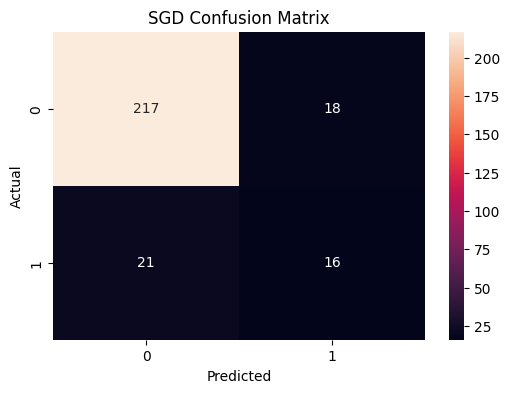

In [ ]:
# confusion Matrix
sgd_cm = confusion_matrix(y_test, sgd_predictions)

plt.figure(figsize=(6, 4))

sns.heatmap(
    sgd_cm,
    annot=True,
    fmt="d"
)

plt.title("SGD Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

## Discussions

### Accuracy

The SGD Classifier achieved an accuracy of **85.66%**.

### Classification Report

The model performed reasonably well on class **0**, but its performance on class **1** was considerably lower.

The weighted F1-score of **0.85** suggests that the model is less effective than Random Forest and SVC in handling the dataset.

### Confusion Matrix

The confusion matrix indicates that SGD correctly classified many observations but made more mistakes when predicting class **1**.

This lower performance may be due to the complexity of the data and the imbalance between the classes.

##SVC Evaluation

In [ ]:
# Accuracy score
svc_accuracy = accuracy_score(y_test, svc_predictions)

print("SVC Accuracy:", svc_accuracy)

print(classification_report(y_test, svc_predictions))

SVC Accuracy: 0.8860294117647058
              precision    recall  f1-score   support

           0       0.90      0.97      0.94       235
           1       0.67      0.32      0.44        37

    accuracy                           0.89       272
   macro avg       0.78      0.65      0.69       272
weighted avg       0.87      0.89      0.87       272



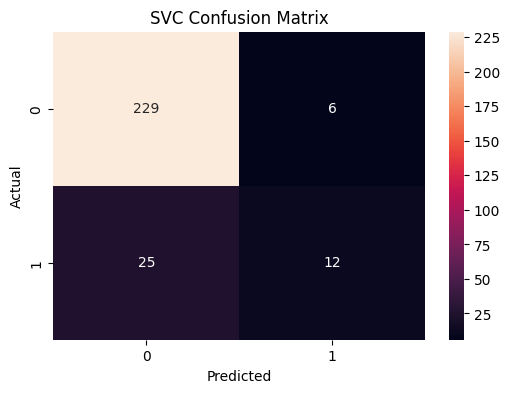

In [ ]:
# confusion Matrix
svc_cm = confusion_matrix(y_test, svc_predictions)

plt.figure(figsize=(6, 4))

sns.heatmap(
    svc_cm,
    annot=True,
    fmt="d"
)

plt.title("SVC Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

## Discussions

### Accuracy

The Support Vector Classifier (SVC) achieved an accuracy of **88.60%**, making it the second-best model in this project.

### Classification Report

The SVC model performed very well on class **0**, achieving high precision and recall scores.

However, the model struggled with class **1**, leading to a lower F1-score for that class.

The weighted average F1-score of **0.87** indicates that the model performed well overall.

### Confusion Matrix

The confusion matrix shows that SVC correctly classified most wine samples but still misclassified several class **1** observations.

Although SVC produced strong results, Random Forest remained the best-performing model.

## 16. Feature Importance

Random Forest provides feature importance scores that indicate how much each physicochemical property contributes to predicting wine quality.

Features with higher importance scores have a greater influence on the model's predictions.

In [ ]:
# Extract feature importances

feature_importance = pd.DataFrame(
    {
        "Feature": X.columns,
        "Importance": rf_model.feature_importances_
    }
)

# Sort features by importance

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance

,Feature,Importance
10,alcohol,0.171173
9,sulphates,0.127573
1,volatile acidity,0.100928
7,density,0.089219
2,citric acid,0.080875
6,total sulfur dioxide,0.080352
0,fixed acidity,0.078449
8,pH,0.073168
4,chlorides,0.070480
5,free sulfur dioxide,0.068652


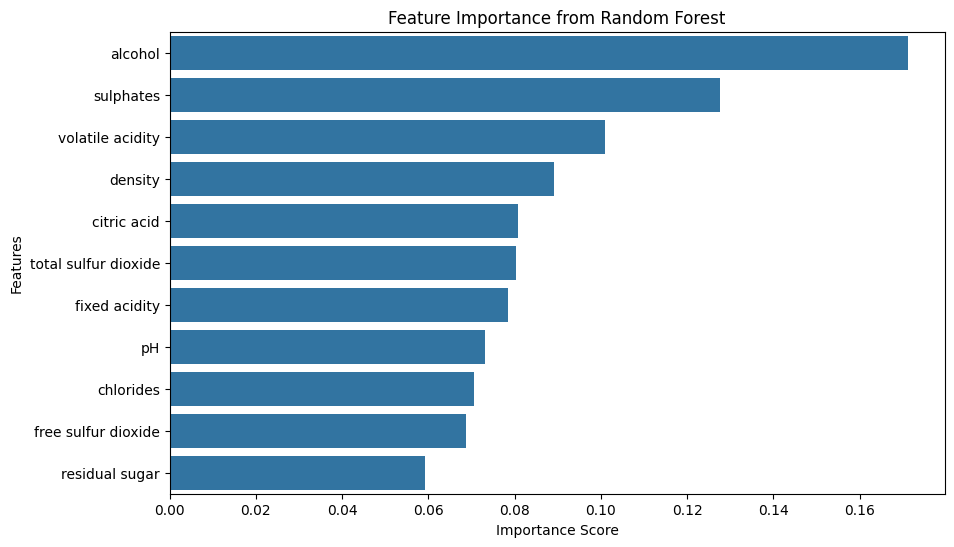

In [ ]:
# plot feature importance
plt.figure(figsize=(10, 6))

sns.barplot(
    data=feature_importance,
    x="Importance",
    y="Feature"
)

plt.title("Feature Importance from Random Forest")
plt.xlabel("Importance Score")
plt.ylabel("Features")

plt.show()

## Discussion

The feature importance analysis shows that alcohol is the most influential feature in predicting wine quality, with the highest importance score. This suggests that wines with different alcohol concentrations are more likely to receive different quality ratings.

Sulphates and volatile acidity are also important predictors of wine quality. In contrast, residual sugar and free sulfur dioxide contribute less to the model's predictions.

The results from the feature importance analysis are consistent with the correlation analysis, where alcohol showed the strongest positive correlation with wine quality, while volatile acidity exhibited a negative relationship.

Overall, alcohol, sulphates, and volatile acidity appear to be the key physicochemical properties affecting wine quality in this dataset.

##17. Model Comparison Table


The performance of the three machine learning models was compared using accuracy and F1-score.

| Model | Accuracy | Weighted F1-Score |
|--------|--------|--------|
| Random Forest | 89.71% | 0.88 |
| SGD Classifier | 85.66% | 0.85 |
| SVC | 88.60% | 0.87 |

### Discussion

- The Random Forest model achieved the highest accuracy of **89.71%**, making it the best-performing model in this project.
- The SVC model performed slightly lower, with an accuracy of **88.60%**.
- The SGD Classifier achieved the lowest accuracy of **85.66%**.
- All models predicted class **0** more effectively than class **1**.
- The lower performance on class **1** is due to the class imbalance observed in the dataset.
- Overall, Random Forest proved to be the most suitable model for predicting wine quality.

##18. Conclusion

In this project, machine learning models were developed to predict wine quality using physicochemical properties such as alcohol content, sulphates, pH, and acidity.

Data preprocessing, exploratory data analysis, feature engineering, train-test splitting, feature scaling, and model training were carried out successfully.

Three classification algorithms—Random Forest, SGD Classifier, and Support Vector Classifier (SVC)—were trained and evaluated. Among the models, Random Forest achieved the best performance with an accuracy of approximately **89.71%**.

Feature importance analysis revealed that alcohol, sulphates, and volatile acidity were among the most influential factors affecting wine quality predictions.

The results demonstrate that machine learning techniques can effectively classify wine quality and that ensemble methods such as Random Forest provide the most reliable predictions for this dataset.